# 16. AI for Sensitivity Analysis

Sensitivity analysis asks a disciplined question:

> How wrong would our causal conclusion be under plausible violations of the assumptions?

This is different from asking whether a coefficient is statistically significant. An observational estimate can be precisely estimated and still be badly biased. A sensitivity analysis makes design fragility visible: unobserved confounding, omitted variables, weak overlap, measurement error, placebo failures, and bad-control risks.

This notebook shows how AI can help structure sensitivity analysis without replacing it. Python computes the evidence. The LLM helps organize interpretation and communication. The audit layer checks whether the model overclaims robustness.

## Mathematical Core

Sensitivity analysis asks how large a hidden bias would need to be to change the conclusion. A simple omitted-variable decomposition is

$$
\mathrm{bias}(\hat\tau) \approx \gamma_{UY} \; \Delta_{UA},
$$

where $\gamma_{UY}$ measures the relationship between the unobserved variable $U$ and outcome $Y$, and $\Delta_{UA}$ measures imbalance in $U$ across treatment groups. The adjusted estimate is then

$$
\hat\tau_{\mathrm{adj}} = \hat\tau - \mathrm{bias}(\hat\tau).
$$

The AI assistant can help narrate scenarios, but the analyst should anchor every scenario in parameters that can be varied and plotted.


## Learning Goals

By the end of this notebook you should be able to:

1. Explain why sensitivity analysis is part of the causal result, not an optional appendix.
2. Estimate a baseline observational effect and compare it with an oracle estimate in synthetic data.
3. Use observed covariates as benchmarks for omitted-variable sensitivity.
4. Build a residual-confounding sensitivity grid that asks how strong an unobserved confounder would need to be.
5. Use placebo outcomes to detect design fragility.
6. Assemble a machine-readable sensitivity report.
7. Use local LLMs to summarize sensitivity evidence while auditing them for overconfident robustness claims.

## Live Model Note

This course treats LLM behavior as an empirical object. These notebooks may include live local-model calls, so outputs can vary across model versions, hardware, decoding settings, prompt wording, package versions, and reruns. That instability is part of the lesson: AI-assisted causal work needs deterministic checks, structured outputs, model comparison, repair logic, and human review.

Sensitivity-analysis notebooks are brittle because the interpretation is subtle. A model may correctly list sensitivity checks but still say “robust” too quickly. It may ignore a placebo failure, confuse oracle synthetic columns with real evidence, or treat a benchmark calculation as proof. We will make those risks explicit and score the model's interpretation against deterministic gates.

## 1. Setup

The deterministic part of this notebook uses a synthetic observational example with a known hidden confounder. In real data we would not observe the hidden confounder; here we keep it for teaching and oracle comparisons.

In [1]:
import importlib.util
import json
import sys
import textwrap
import warnings
from pathlib import Path
from typing import Literal

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import statsmodels.formula.api as smf
import torch
from IPython.display import Markdown, display
from pydantic import BaseModel, Field
from sklearn.linear_model import LinearRegression

warnings.filterwarnings('ignore', category=FutureWarning)

from notebooks._shared.display import smart_display


In [2]:
# Section focus: 1. Setup.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

RUN_LIVE_LOCAL_LLM = True
RUN_FULL_MODEL_COMPARISON = True
RUN_SCHEMA_REPAIR_RETRY = True

LOCAL_SMOKE_TEST_MODEL = 'Qwen/Qwen2.5-0.5B-Instruct'
LOCAL_FAST_MODEL = 'Qwen/Qwen2.5-7B-Instruct'
LOCAL_STRONG_MODEL = 'Qwen/Qwen2.5-14B-Instruct'
LOCAL_SCALE_MODEL = 'Qwen/Qwen2.5-32B-Instruct'

LOCAL_ALT_REASONING_MODEL = 'microsoft/Phi-3.5-mini-instruct'
LOCAL_ALT_OPEN_MODEL = 'mistralai/Mistral-7B-Instruct-v0.3'
LOCAL_MISTRAL_SMALL_MODEL = 'mistralai/Mistral-Small-3.1-24B-Instruct-2503'
LOCAL_GEMMA_MODEL = 'google/gemma-3-27b-it'
LOCAL_LLAMA_MODEL = 'meta-llama/Meta-Llama-3.1-8B-Instruct'

MODEL_ID = LOCAL_STRONG_MODEL
MAX_NEW_TOKENS = 1900
TEMPERATURE = 0.0
SEED = 216
MODEL_COMPARISON_CASE_LIMIT = 2

MODELS_TO_COMPARE = [
    ('Qwen 0.5B', LOCAL_SMOKE_TEST_MODEL, 'pipeline smoke test'),
    ('Qwen 7B', LOCAL_FAST_MODEL, 'fast default'),
    ('Qwen 14B', LOCAL_STRONG_MODEL, 'strong local analysis'),
    ('Qwen 32B', LOCAL_SCALE_MODEL, 'scale comparison'),
    ('Phi mini', LOCAL_ALT_REASONING_MODEL, 'compact non-Qwen comparison'),
    ('Mistral 7B', LOCAL_ALT_OPEN_MODEL, '7B model-family comparison'),
    ('Mistral Small 24B', LOCAL_MISTRAL_SMALL_MODEL, 'strong non-Qwen comparison'),
    ('Gemma 3 27B', LOCAL_GEMMA_MODEL, 'large non-Qwen comparison'),
    ('Llama 3.1 8B', LOCAL_LLAMA_MODEL, 'industry-standard instruct baseline'),
]

np.random.seed(SEED)
sns.set_theme(style='whitegrid', context='notebook')
pd.set_option('display.max_colwidth', 160)

In [3]:
# Section focus: 1. Setup.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

def has_package(module_name):
    """Carry out the has package step used in the 16. AI for Sensitivity Analysis workflow.
    
    Parameters
    ----------
    module_name : object
        Name of the Python package or notebook module being checked for availability.
    
    Returns
    -------
    object
        Intermediate result produced by the has package calculation and reused by later cells.
    """
    return importlib.util.find_spec(module_name) is not None

package_status = pd.DataFrame(
    [
        {'package': 'pandas', 'available': has_package('pandas'), 'used_for': 'sensitivity tables'},
        {'package': 'statsmodels', 'available': has_package('statsmodels'), 'used_for': 'effect and placebo regressions'},
        {'package': 'sklearn', 'available': has_package('sklearn'), 'used_for': 'residualization helpers'},
        {'package': 'seaborn', 'available': has_package('seaborn'), 'used_for': 'sensitivity plots'},
        {'package': 'pydantic', 'available': has_package('pydantic'), 'used_for': 'structured AI sensitivity review'},
        {'package': 'transformers', 'available': has_package('transformers'), 'used_for': 'optional local LLM review'},
        {'package': 'torch', 'available': has_package('torch'), 'used_for': 'GPU inference if live LLMs are enabled'},
    ]
)

print(f'CUDA available to this kernel: {torch.cuda.is_available()}')
smart_display(package_status)

CUDA available to this kernel: True


,package,available,used_for
0,pandas,True,sensitivity tables
1,statsmodels,True,effect and placebo regressions
2,sklearn,True,residualization helpers
3,seaborn,True,sensitivity plots
4,pydantic,True,structured AI sensitivity review
5,transformers,True,optional local LLM review
6,torch,True,GPU inference if live LLMs are enabled


## 2. What Sensitivity Analysis Is For

Sensitivity analysis is not pessimism. It is disciplined honesty.

A standard adjusted estimate says:

> Under the stated assumptions, this is the estimated effect.

A sensitivity analysis adds:

> If the assumptions are wrong in these specific ways, this is how the estimate would move.

The second sentence is often the difference between a defensible causal report and a brittle dashboard claim.

| component | question | what it teaches |
|---|---|---|
| Benchmark confounders | How much does the treatment effect move when important observed covariates are omitted? | Plausible scale for omitted-variable bias. |
| Residual confounding grid | How strong would a hidden confounder need to be with residual treatment and outcome? | Tipping points for sign reversal or loss of practical significance. |
| Placebo outcome | Does treatment appear to affect an outcome measured before treatment? | Evidence of residual confounding or selection. |
| Oracle comparison in simulation | How far is feasible adjustment from the estimate that includes hidden truth variables? | What the observed analysis is missing in a controlled lab. |
| Communication warning | What should stakeholders not conclude from this estimate? | Prevents robustness language from becoming overclaiming. |


No single sensitivity method is universal. The right set depends on the design: unmeasured confounding for observational adjustment, pre-trends for DiD, exclusion violations for IV, manipulation for RDD, interference for experiments, and logging-policy overlap for off-policy evaluation.

## 3. Running Example: Onboarding Specialist Assignment

A SaaS company assigns some customers to a specialist onboarding program. The business asks:

> What is the effect of specialist onboarding on 90-day net revenue?

Assignment is observational. Managers prioritize accounts with high value, high risk, and signs of executive attention. Some of that attention is recorded; some is not. We simulate the hidden variable so we can teach sensitivity analysis.

The row grain is a customer account at the time an onboarding specialist may be assigned. The observed data include account value, baseline risk, usage, segment, and recorded executive attention. The simulation also includes unrecorded executive attention, which affects both assignment and revenue. That hidden variable is visible only for teaching.

The experiment asks how much unobserved confounding would be needed to change the conclusion. We compare the baseline adjusted estimate, an oracle estimate that uses the hidden variable, and sensitivity grids benchmarked against observed covariates. The AI layer is used to draft cautious interpretation, not to decide whether the assumption is true.


In [5]:
# Section focus: 3. Running Example: Onboarding Specialist Assignment.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

def sigmoid(x):
    """Map a linear score to a probability-like value for the notebook simulation.
    
    Parameters
    ----------
    x : object
        Numeric score, scalar, or array passed through the transformation in this helper.
    
    Returns
    -------
    object
        Numeric diagnostic, score, or transformed value from the sigmoid calculation.
    """
    return 1 / (1 + np.exp(-x))


def simulate_onboarding_data(n=5200, seed=SEED, hidden_strength=0.65, overlap_noise=0.75):
    """Create a simulated onboarding data set for the 16. AI for Sensitivity Analysis case study.
    
    Parameters
    ----------
    n : object
        Number of observations or simulation units used by the calculation.
    seed : object
        Random seed used to make the simulation reproducible.
    hidden_strength : object
        The hidden strength setting that controls the onboarding data calculation in this notebook.
    overlap_noise : object
        The overlap noise setting that controls the onboarding data calculation in this notebook.
    
    Returns
    -------
    object
        Tuple of outputs from this workflow, usually data, fitted objects, or diagnostics used by later cells.
    """
    rng = np.random.default_rng(seed)
    segment = rng.choice(['startup', 'midmarket', 'enterprise'], size=n, p=[0.46, 0.38, 0.16])
    region = rng.choice(['Americas', 'EMEA', 'APAC'], size=n, p=[0.48, 0.33, 0.19])
    tenure_months = rng.gamma(shape=2.5, scale=7.5, size=n).clip(1, 72)
    baseline_usage = rng.normal(0, 1, size=n)
    prior_support_tickets = rng.poisson(np.exp(-0.20 - 0.18 * baseline_usage + 0.24 * (segment == 'enterprise')), size=n)
    contract_value = np.exp(3.3 + 0.45 * (segment == 'enterprise') + 0.18 * baseline_usage + rng.normal(0, 0.42, size=n))
    observed_health = 0.62 * baseline_usage + 0.018 * tenure_months - 0.24 * prior_support_tickets + 0.18 * (region == 'Americas') + rng.normal(0, 0.58, size=n)
    risk_score = -0.86 * observed_health + 0.30 * prior_support_tickets + 0.12 * np.log1p(contract_value) + rng.normal(0, 0.45, size=n)

    executive_attention = rng.normal(0, 1, size=n)
    prior_period_revenue = (
        24
        + 0.34 * contract_value
        + 7.0 * observed_health
        + hidden_strength * 7.5 * executive_attention
        + rng.normal(0, 18, size=n)
    )

    assignment_logit = (
        -0.25
        + 1.05 * risk_score
        + 0.24 * np.log1p(contract_value)
        + 0.18 * (segment == 'enterprise')
        + hidden_strength * 0.85 * executive_attention
        + rng.normal(0, overlap_noise, size=n)
    )
    onboarding_specialist = rng.binomial(1, sigmoid(assignment_logit))

    true_effect = 7.0 + 2.0 * sigmoid(risk_score) + 1.2 * (segment == 'enterprise')
    net_revenue_90d = (
        30
        + 0.42 * contract_value
        + 10.0 * observed_health
        - 2.0 * prior_support_tickets
        + hidden_strength * 9.0 * executive_attention
        + true_effect * onboarding_specialist
        + rng.normal(0, 22, size=n)
    )
    product_adoption_30d = 0.45 * baseline_usage + 0.55 * onboarding_specialist + 0.30 * executive_attention + rng.normal(0, 1, size=n)
    expansion_pipeline_120d = net_revenue_90d + 0.20 * contract_value + 12 * onboarding_specialist + rng.normal(0, 20, size=n)

    df = pd.DataFrame(
        {
            'account_id': [f'A{idx:05d}' for idx in range(n)],
            'segment': segment,
            'region': region,
            'tenure_months': tenure_months,
            'baseline_usage': baseline_usage,
            'prior_support_tickets': prior_support_tickets,
            'contract_value': contract_value,
            'observed_health': observed_health,
            'risk_score': risk_score,
            'executive_attention': executive_attention,
            'prior_period_revenue': prior_period_revenue,
            'onboarding_specialist': onboarding_specialist,
            'true_effect': true_effect,
            'net_revenue_90d': net_revenue_90d,
            'product_adoption_30d': product_adoption_30d,
            'expansion_pipeline_120d': expansion_pipeline_120d,
        }
    )
    truth = {
        'true_ate': float(df['true_effect'].mean()),
        'true_att': float(df.loc[df['onboarding_specialist'].eq(1), 'true_effect'].mean()),
        'treatment_rate': float(df['onboarding_specialist'].mean()),
        'hidden_strength': hidden_strength,
    }
    return df, truth

raw, truth = simulate_onboarding_data()
raw.head()

,account_id,segment,region,tenure_months,baseline_usage,prior_support_tickets,contract_value,observed_health,risk_score,executive_attention,prior_period_revenue,onboarding_specialist,true_effect,net_revenue_90d,product_adoption_30d,expansion_pipeline_120d
0,A00000,enterprise,Americas,19.767521,1.440981,1,42.053951,0.372740,0.646366,-0.881831,35.639973,0,9.512382,73.822233,1.491241,125.168395
1,A00001,midmarket,Americas,2.714544,-0.799302,0,37.342631,0.143256,0.532391,0.166796,24.695390,1,8.260081,96.890555,-0.940938,108.780270
2,A00002,startup,EMEA,54.283982,-1.945033,1,10.483906,0.664454,-0.882747,-1.052783,1.203831,1,7.585218,38.893951,-0.752022,43.501021
3,A00003,midmarket,Americas,20.707722,-0.813210,3,12.673929,-0.047837,2.111590,0.039967,43.765324,1,8.784049,30.239183,-1.263760,37.587590
4,A00004,midmarket,EMEA,17.547371,-1.420773,1,38.000833,-0.279677,0.550063,-1.428694,14.994348,0,8.268300,78.246247,-0.659701,56.833462


Treat this output as evidence about the AI-assisted workflow. In Running Example: Onboarding Specialist Assignment, check whether the response stays grounded, preserves the estimand or task contract, and names uncertainty. The workflow improves when repairs turn into repeatable tests.


In [6]:
smart_display(truth)

{'true_ate': 8.388275446972925,
 'true_att': 8.50067894836023,
 'treatment_rate': 0.685,
 'hidden_strength': 0.65}

The Running Example: Onboarding Specialist Assignment table should be read as an operating comparison. Wide gaps and concentrated failures point to the next validation step before deployment.


## 4. Analysis Contract and Variable Roles

The sensitivity report is tied to a specific estimand and variable role map. The hidden variable is included only because this is a synthetic teaching notebook.

In [7]:
# Section focus: 4. Analysis Contract and Variable Roles.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

analysis_contract = {
    'analysis_id': 'onboarding_specialist_sensitivity_v1',
    'estimand': 'ATE of onboarding_specialist on net_revenue_90d among eligible accounts',
    'treatment': 'onboarding_specialist',
    'outcome': 'net_revenue_90d',
    'placebo_outcome': 'prior_period_revenue',
    'allowed_covariates': [
        'segment',
        'region',
        'tenure_months',
        'baseline_usage',
        'prior_support_tickets',
        'contract_value',
        'observed_health',
        'risk_score',
    ],
    'categorical_covariates': ['segment', 'region'],
    'oracle_hidden_confounders': ['executive_attention'],
    'forbidden_variables': ['product_adoption_30d', 'expansion_pipeline_120d', 'true_effect'],
    'diagnostic_thresholds': {
        'placebo_caution_revenue_units': 4.0,
        'tipping_point_distance_caution': 0.35,
        'benchmark_shift_caution_ratio': 1.0,
    },
}

variable_roles = pd.DataFrame(
    [{'variable': var, 'role': 'allowed pre-treatment covariate'} for var in analysis_contract['allowed_covariates']]
    + [{'variable': analysis_contract['treatment'], 'role': 'treatment'}]
    + [{'variable': analysis_contract['outcome'], 'role': 'outcome'}]
    + [{'variable': analysis_contract['placebo_outcome'], 'role': 'pre-treatment placebo outcome'}]
    + [{'variable': var, 'role': 'oracle hidden confounder for teaching only'} for var in analysis_contract['oracle_hidden_confounders']]
    + [{'variable': var, 'role': 'forbidden post-treatment/future/oracle variable'} for var in analysis_contract['forbidden_variables']]
)
smart_display(variable_roles)

,variable,role
0,segment,allowed pre-treatment covariate
1,region,allowed pre-treatment covariate
2,tenure_months,allowed pre-treatment covariate
3,baseline_usage,allowed pre-treatment covariate
4,prior_support_tickets,allowed pre-treatment covariate
5,contract_value,allowed pre-treatment covariate
6,observed_health,allowed pre-treatment covariate
7,risk_score,allowed pre-treatment covariate
8,onboarding_specialist,treatment
9,net_revenue_90d,outcome


The forbidden variables are important. `product_adoption_30d` is post-treatment. `expansion_pipeline_120d` is future-looking. `true_effect` is simulation truth. Sensitivity analysis should not quietly turn these into controls.

These numbers translate model behavior into decision consequences. For Analysis Contract and Variable Roles, compare the metrics by the failure they expose: missed positives, false alarms, poor calibration, unstable thresholds, or weak subgroup performance. A model is ready for action only when those tradeoffs are visible.


## 5. Baseline, Oracle, and Placebo Estimates

We estimate three models:

1. A feasible adjusted model using observed pre-treatment covariates.
2. An oracle model that additionally controls for the hidden confounder. This is for teaching only.
3. A placebo model using the same adjustment set but with a pre-treatment outcome.

In [8]:
# Section focus: 5. Baseline, Oracle, and Placebo Estimates.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

def formula_term(variable, categorical):
    """Carry out the formula term step used in the 16. AI for Sensitivity Analysis workflow.
    
    Parameters
    ----------
    variable : object
        Column or variable name used to select information from the input table.
    categorical : object
        The categorical setting that controls the formula term calculation in this notebook.
    
    Returns
    -------
    object
        Intermediate result produced by the formula term calculation and reused by later cells.
    """
    return f'C({variable})' if variable in categorical else variable


def build_formula(outcome, treatment, covariates, categorical):
    """Build the formula object used in the 16. AI for Sensitivity Analysis analysis.
    
    Parameters
    ----------
    outcome : object
        Outcome variable whose behavior is being modeled or compared.
    treatment : object
        Treatment or intervention indicator used by the causal workflow.
    covariates : object
        Adjustment or feature columns representing observed pre-decision information.
    categorical : object
        The categorical setting that controls the formula calculation in this notebook.
    
    Returns
    -------
    object
        Intermediate result produced by the formula calculation and reused by later cells.
    """
    terms = [formula_term(var, categorical) for var in covariates]
    return f"{outcome} ~ {treatment} + " + ' + '.join(terms)


def fit_effect_model(df, outcome, treatment, covariates, categorical):
    """Fit the effect model model or object used in the 16. AI for Sensitivity Analysis analysis.
    
    Parameters
    ----------
    df : object
        Input data frame containing the rows used in this notebook example.
    outcome : object
        Outcome variable whose behavior is being modeled or compared.
    treatment : object
        Treatment or intervention indicator used by the causal workflow.
    covariates : object
        Adjustment or feature columns representing observed pre-decision information.
    categorical : object
        The categorical setting that controls the effect model calculation in this notebook.
    
    Returns
    -------
    object
        Dictionary or table of metrics used to compare model behavior.
    """
    formula = build_formula(outcome, treatment, covariates, categorical)
    fitted = smf.ols(formula, data=df).fit(cov_type='HC3')
    estimate = fitted.params[treatment]
    se = fitted.bse[treatment]
    return {
        'formula': formula,
        'estimate': float(estimate),
        'robust_se': float(se),
        'ci_low': float(estimate - 1.96 * se),
        'ci_high': float(estimate + 1.96 * se),
        'p_value': float(fitted.pvalues[treatment]),
        'rows': int(fitted.nobs),
        'model': fitted,
    }

observed_result = fit_effect_model(
    raw,
    analysis_contract['outcome'],
    analysis_contract['treatment'],
    analysis_contract['allowed_covariates'],
    analysis_contract['categorical_covariates'],
)
oracle_result = fit_effect_model(
    raw,
    analysis_contract['outcome'],
    analysis_contract['treatment'],
    analysis_contract['allowed_covariates'] + analysis_contract['oracle_hidden_confounders'],
    analysis_contract['categorical_covariates'],
)
placebo_result = fit_effect_model(
    raw,
    analysis_contract['placebo_outcome'],
    analysis_contract['treatment'],
    analysis_contract['allowed_covariates'],
    analysis_contract['categorical_covariates'],
)

estimate_table = pd.DataFrame(
    [
        {'model': 'observed adjusted', 'target': 'outcome', **{k: v for k, v in observed_result.items() if k != 'model'}},
        {'model': 'oracle hidden-confounder adjusted', 'target': 'outcome', **{k: v for k, v in oracle_result.items() if k != 'model'}},
        {'model': 'observed adjusted placebo', 'target': 'placebo', **{k: v for k, v in placebo_result.items() if k != 'model'}},
    ]
)
estimate_table[['model', 'target', 'estimate', 'robust_se', 'ci_low', 'ci_high', 'p_value', 'rows']]

,model,target,estimate,robust_se,ci_low,ci_high,p_value,rows
0,observed adjusted,outcome,9.757901,0.729626,8.327834,11.187967,8.597864e-41,5200
1,oracle hidden-confounder adjusted,outcome,7.336248,0.717084,5.930764,8.741732,1.445147e-24,5200
2,observed adjusted placebo,placebo,2.194321,0.604380,1.009736,3.378906,2.826560e-04,5200


Here the analysis leaves the leaderboard and enters the workflow. The useful reading is which metric would change the action in Baseline, Oracle, and Placebo Estimates. A defensible choice starts by naming the costly mistake.


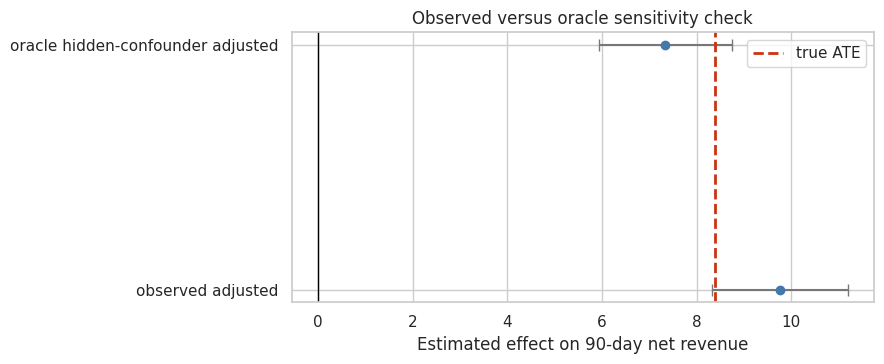

In [9]:
fig, ax = plt.subplots(figsize=(9, 3.8))
plot_estimates = estimate_table.query("target == 'outcome'").copy()
ax.errorbar(
    plot_estimates['estimate'],
    plot_estimates['model'],
    xerr=[plot_estimates['estimate'] - plot_estimates['ci_low'], plot_estimates['ci_high'] - plot_estimates['estimate']],
    fmt='o',
    color='#4477AA',
    ecolor='#777777',
    capsize=4,
)
ax.axvline(truth['true_ate'], color='#CC3311', linestyle='--', linewidth=2, label='true ATE')
ax.axvline(0, color='black', linewidth=1)
ax.set_title('Observed versus oracle sensitivity check')
ax.set_xlabel('Estimated effect on 90-day net revenue')
ax.set_ylabel('')
ax.legend()
plt.tight_layout()
plt.show()

The oracle comparison is a teaching device. In a real project we do not have `executive_attention`. If the oracle estimate differs from the observed-adjusted estimate, it shows why hidden confounding matters.

The placebo estimate is also important. Current treatment cannot cause prior-period revenue. A nonzero placebo effect is a warning about residual confounding or selection.

## 6. Benchmark Confounder Analysis

One practical sensitivity habit is to ask:

> How much does the treatment coefficient move when important observed covariates are removed?

Those movements do not prove how large unobserved confounding is, but they give a scale for reasoning about omitted variables.

In [10]:
# Section focus: 6. Benchmark Confounder Analysis.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

def refit_without_covariate(df, contract, omitted):
    """Carry out the refit without covariate step used in the 16. AI for Sensitivity Analysis workflow.
    
    Parameters
    ----------
    df : object
        Input data frame containing the rows used in this notebook example.
    contract : object
        Structured specification of the analysis requirements being checked or executed.
    omitted : object
        The omitted setting that controls the refit without covariate calculation in this notebook.
    
    Returns
    -------
    object
        Fitted model, transformer, or configuration object from the refit without covariate workflow.
    """
    covariates = [var for var in contract['allowed_covariates'] if var != omitted]
    categorical = [var for var in contract['categorical_covariates'] if var in covariates]
    result = fit_effect_model(df, contract['outcome'], contract['treatment'], covariates, categorical)
    return result['estimate']

benchmark_rows = []
for covariate in analysis_contract['allowed_covariates']:
    reduced_estimate = refit_without_covariate(raw, analysis_contract, covariate)
    shift = reduced_estimate - observed_result['estimate']
    benchmark_rows.append(
        {
            'omitted_covariate': covariate,
            'estimate_without_covariate': reduced_estimate,
            'shift_from_full_model': shift,
            'abs_shift': abs(shift),
            'shift_as_share_of_estimate': abs(shift) / abs(observed_result['estimate']),
        }
    )
benchmark_table = pd.DataFrame(benchmark_rows).sort_values('abs_shift', ascending=False)
smart_display(benchmark_table)

,omitted_covariate,estimate_without_covariate,shift_from_full_model,abs_shift,shift_as_share_of_estimate
7,risk_score,10.041754,0.283853,0.283853,0.029090
5,contract_value,10.013070,0.255169,0.255169,0.026150
6,observed_health,9.734774,-0.023127,0.023127,0.002370
0,segment,9.776957,0.019056,0.019056,0.001953
4,prior_support_tickets,9.741525,-0.016376,0.016376,0.001678
1,region,9.768545,0.010644,0.010644,0.001091
2,tenure_months,9.765030,0.007129,0.007129,0.000731
3,baseline_usage,9.752294,-0.005607,0.005607,0.000575


The table gives the literature claim a form that can be audited. For Benchmark Confounder Analysis, the important reading is the pattern across rows, the pattern across rows together with the largest values. The next step should be visible from the pattern.


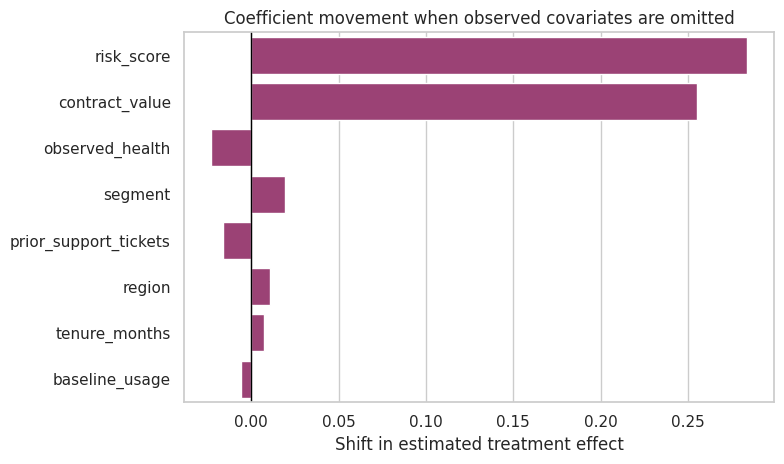

In [11]:
fig, ax = plt.subplots(figsize=(8, 4.8))
sns.barplot(data=benchmark_table, y='omitted_covariate', x='shift_from_full_model', color='#AA3377', ax=ax)
ax.axvline(0, color='black', linewidth=1)
ax.set_title('Coefficient movement when observed covariates are omitted')
ax.set_xlabel('Shift in estimated treatment effect')
ax.set_ylabel('')
plt.tight_layout()
plt.show()

If omitting one observed covariate moves the estimate substantially, then an unobserved covariate of comparable importance could also matter. Benchmarking makes that conversation concrete.

Read the plot as a diagnostic for the workflow. The main question is what visible pattern would change the analysis in Benchmark Confounder Analysis. Clean separation makes a simple rule easier to defend. Overlap or unusual tails call for more careful diagnostics.


## 7. Residual-Confounding Sensitivity Grid

We now ask a hypothetical question:

> Suppose there is one unobserved confounder left after adjusting for observed covariates. If that confounder has correlation `r_tu` with the residualized treatment and `r_yu` with the residualized outcome, how would the treatment coefficient change?

This is a stylized sensitivity analysis. It is not a substitute for design knowledge, but it makes the tipping point visible.

In [12]:
# Section focus: 7. Residual-Confounding Sensitivity Grid.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

def design_matrix_for_contract(df, covariates, categorical):
    """Carry out the design matrix for contract step used in the 16. AI for Sensitivity Analysis workflow.
    
    Parameters
    ----------
    df : object
        Input data frame containing the rows used in this notebook example.
    covariates : object
        Adjustment or feature columns representing observed pre-decision information.
    categorical : object
        The categorical setting that controls the design matrix for contract calculation in this notebook.
    
    Returns
    -------
    object
        Tabular or matrix-style object produced by the design matrix for contract workflow for later analysis.
    """
    X = pd.get_dummies(df[covariates], columns=categorical, drop_first=True, dtype=float)
    X = pd.concat([pd.Series(1.0, index=X.index, name='intercept'), X], axis=1)
    return X


def residualize(series, X):
    """Carry out the residualize step used in the 16. AI for Sensitivity Analysis workflow.
    
    Parameters
    ----------
    series : object
        One-dimensional pandas object whose distribution or most common value is being inspected.
    X : object
        Feature matrix used for fitting, prediction, or diagnostics.
    
    Returns
    -------
    object
        Intermediate result produced by the residualize calculation and reused by later cells.
    """
    y = np.asarray(series, dtype=float)
    beta = np.linalg.lstsq(np.asarray(X, dtype=float), y, rcond=None)[0]
    return y - np.asarray(X, dtype=float) @ beta


def coefficient_with_unobserved_confounder(resid_t, resid_y, r_tu, r_yu):
    """Carry out the coefficient with unobserved confounder step used in the 16. AI for Sensitivity Analysis workflow.
    
    Parameters
    ----------
    resid_t : object
        The resid t setting that controls the coefficient with unobserved confounder calculation in this notebook.
    resid_y : object
        The resid y setting that controls the coefficient with unobserved confounder calculation in this notebook.
    r_tu : object
        The r tu setting that controls the coefficient with unobserved confounder calculation in this notebook.
    r_yu : object
        The r yu setting that controls the coefficient with unobserved confounder calculation in this notebook.
    
    Returns
    -------
    object
        Intermediate result produced by the coefficient with unobserved confounder calculation and reused by later cells.
    """
    resid_t = np.asarray(resid_t, dtype=float)
    resid_y = np.asarray(resid_y, dtype=float)
    var_t = np.var(resid_t, ddof=0)
    var_y = np.var(resid_y, ddof=0)
    cov_ty = np.mean((resid_t - resid_t.mean()) * (resid_y - resid_y.mean()))
    sd_t = np.sqrt(var_t)
    sd_y = np.sqrt(var_y)
    cov_tu = r_tu * sd_t
    cov_yu = r_yu * sd_y
    denom = var_t - cov_tu ** 2
    if denom <= 1e-12:
        return np.nan
    return (cov_ty - cov_tu * cov_yu) / denom

X_observed = design_matrix_for_contract(raw, analysis_contract['allowed_covariates'], analysis_contract['categorical_covariates'])
resid_t = residualize(raw[analysis_contract['treatment']], X_observed)
resid_y = residualize(raw[analysis_contract['outcome']], X_observed)
resid_placebo = residualize(raw[analysis_contract['placebo_outcome']], X_observed)

r_values = np.round(np.linspace(-0.60, 0.60, 49), 3)
grid_rows = []
for r_tu in r_values:
    for r_yu in r_values:
        adjusted_coef = coefficient_with_unobserved_confounder(resid_t, resid_y, r_tu, r_yu)
        grid_rows.append({'r_tu': r_tu, 'r_yu': r_yu, 'sensitivity_adjusted_effect': adjusted_coef})
sensitivity_grid = pd.DataFrame(grid_rows)
sensitivity_grid.head()

,r_tu,r_yu,sensitivity_adjusted_effect
0,-0.6,-0.600,-14.525436
1,-0.6,-0.575,-13.284929
2,-0.6,-0.550,-12.044423
3,-0.6,-0.525,-10.803916
4,-0.6,-0.500,-9.563410


Use this table as a compact audit record. It shows which cases, segments, models, or assumptions carry the most weight in Residual-Confounding Sensitivity Grid. A surprising row should become the next diagnostic target.


In [13]:
zero_crossing = sensitivity_grid.query('sensitivity_adjusted_effect <= 0').copy()
if zero_crossing.empty:
    tipping_point = {'exists_in_grid': False, 'min_correlation_distance': np.nan, 'r_tu': np.nan, 'r_yu': np.nan, 'effect_at_tipping_point': np.nan}
else:
    zero_crossing['correlation_distance'] = np.sqrt(zero_crossing['r_tu'] ** 2 + zero_crossing['r_yu'] ** 2)
    row = zero_crossing.sort_values('correlation_distance').iloc[0]
    tipping_point = {
        'exists_in_grid': True,
        'min_correlation_distance': float(row['correlation_distance']),
        'r_tu': float(row['r_tu']),
        'r_yu': float(row['r_yu']),
        'effect_at_tipping_point': float(row['sensitivity_adjusted_effect']),
    }

smart_display(tipping_point)

{'exists_in_grid': True,
 'min_correlation_distance': 0.6189709201569974,
 'r_tu': 0.425,
 'r_yu': 0.45,
 'effect_at_tipping_point': -0.44501253597670876}

This table should help the reader challenge the design rather than accept it passively. For Residual-Confounding Sensitivity Grid, the important reading is the pattern across rows, the pattern across rows together with the largest values. Let the pattern guide the next operating decision.


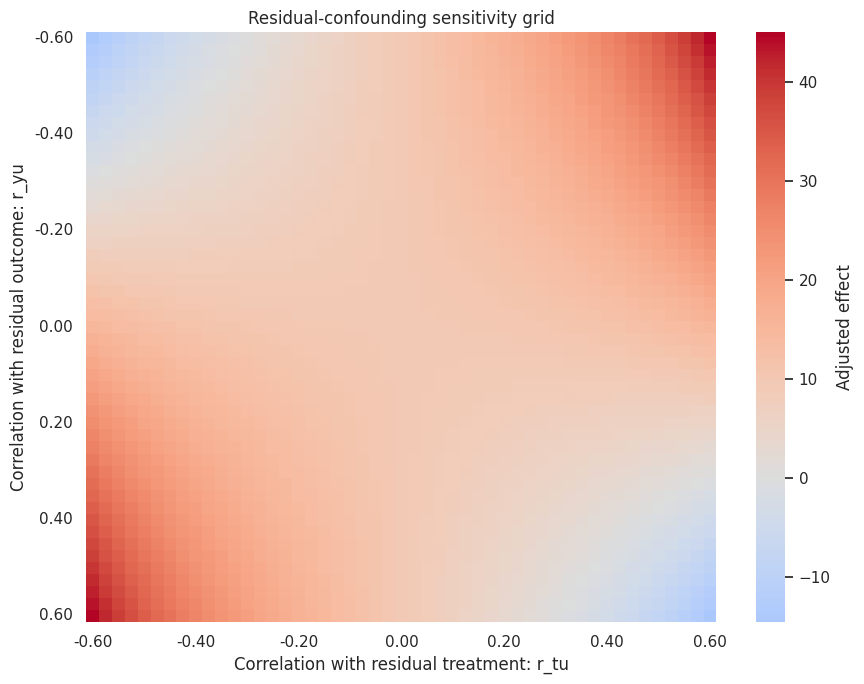

In [14]:
heatmap_data = sensitivity_grid.pivot(index='r_yu', columns='r_tu', values='sensitivity_adjusted_effect')
fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(heatmap_data, cmap='coolwarm', center=0, cbar_kws={'label': 'Adjusted effect'}, ax=ax)
ax.set_title('Residual-confounding sensitivity grid')
ax.set_xlabel('Correlation with residual treatment: r_tu')
ax.set_ylabel('Correlation with residual outcome: r_yu')
xticks = np.linspace(0, len(r_values) - 1, 7, dtype=int)
yticks = np.linspace(0, len(r_values) - 1, 7, dtype=int)
ax.set_xticks(xticks + 0.5)
ax.set_xticklabels([f'{r_values[i]:.2f}' for i in xticks], rotation=0)
ax.set_yticks(yticks + 0.5)
ax.set_yticklabels([f'{r_values[i]:.2f}' for i in yticks], rotation=0)
plt.tight_layout()
plt.show()

The grid is not saying that a particular hidden confounder exists. It is saying how strong one would need to be, on the residual scale, to change the conclusion.

If the effect reverses under very small residual correlations, the design is fragile. If reversal requires implausibly strong residual correlations, the estimate is more robust to this specific form of hidden confounding. That still does not prove causality.

## 8. Placebo Outcome Sensitivity

A placebo outcome gives a different lens. Since treatment happens after prior-period revenue, any apparent effect on `prior_period_revenue` is evidence that treated and untreated accounts differ in ways the observed model has not fully removed.

In [15]:
placebo_summary = {
    'placebo_outcome': analysis_contract['placebo_outcome'],
    'placebo_estimate': placebo_result['estimate'],
    'placebo_robust_se': placebo_result['robust_se'],
    'placebo_ci_low': placebo_result['ci_low'],
    'placebo_ci_high': placebo_result['ci_high'],
    'absolute_placebo_estimate': abs(placebo_result['estimate']),
    'placebo_as_share_of_observed_effect': abs(placebo_result['estimate']) / abs(observed_result['estimate']),
}
smart_display(placebo_summary)

{'placebo_outcome': 'prior_period_revenue',
 'placebo_estimate': 2.1943210894276772,
 'placebo_robust_se': 0.6043799867184138,
 'placebo_ci_low': 1.0097363154595862,
 'placebo_ci_high': 3.3789058633957683,
 'absolute_placebo_estimate': 2.1943210894276772,
 'placebo_as_share_of_observed_effect': 0.2248763474696809}

Use this table as a compact audit record. It shows which cases, segments, models, or assumptions carry the most weight in Placebo Outcome Sensitivity. A standout row deserves a second look before it becomes a conclusion.


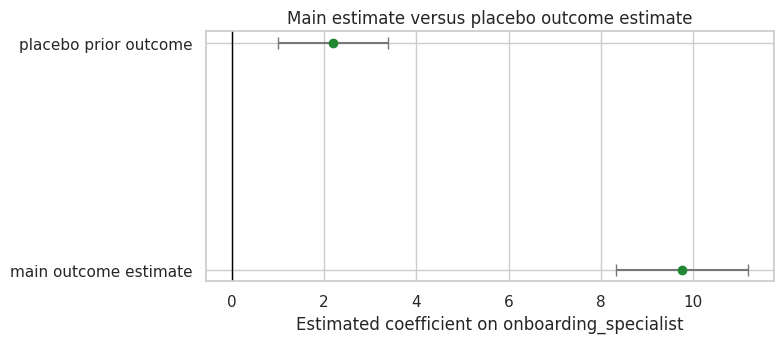

In [16]:
fig, ax = plt.subplots(figsize=(8, 3.6))
placebo_plot = pd.DataFrame(
    [
        {'estimand': 'main outcome estimate', 'estimate': observed_result['estimate'], 'ci_low': observed_result['ci_low'], 'ci_high': observed_result['ci_high']},
        {'estimand': 'placebo prior outcome', 'estimate': placebo_result['estimate'], 'ci_low': placebo_result['ci_low'], 'ci_high': placebo_result['ci_high']},
    ]
)
ax.errorbar(
    placebo_plot['estimate'],
    placebo_plot['estimand'],
    xerr=[placebo_plot['estimate'] - placebo_plot['ci_low'], placebo_plot['ci_high'] - placebo_plot['estimate']],
    fmt='o',
    color='#228833',
    ecolor='#777777',
    capsize=4,
)
ax.axvline(0, color='black', linewidth=1)
ax.set_title('Main estimate versus placebo outcome estimate')
ax.set_xlabel('Estimated coefficient on onboarding_specialist')
ax.set_ylabel('')
plt.tight_layout()
plt.show()

A placebo failure does not tell us the exact bias in the main outcome. It tells us the design can produce an apparent treatment effect where no treatment effect should exist. That should change how cautiously we communicate the main estimate.

This figure is meant to make the pattern visible. In Placebo Outcome Sensitivity, the shape, separation, overlap, tail behavior, or clustering should be tied back to a modeling choice or guardrail. A decision workflow should use the visual pattern to decide where the model is credible and where the next diagnostic needs attention.


## 9. Sensitivity Gates

We now turn the sensitivity evidence into a decision recommendation. The gates are deliberately conservative.

In [17]:
# Section focus: 9. Sensitivity Gates.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

def classify_sensitivity_gates(observed_result, oracle_result, benchmark_table, placebo_summary, tipping_point, contract):
    """Carry out the classify sensitivity gates step used in the 16. AI for Sensitivity Analysis workflow.
    
    Parameters
    ----------
    observed_result : object
        The observed result setting that controls the classify sensitivity gates calculation in this notebook.
    oracle_result : object
        The oracle result setting that controls the classify sensitivity gates calculation in this notebook.
    benchmark_table : object
        Tabular data object used as the input or output of this workflow step.
    placebo_summary : object
        The placebo summary setting that controls the classify sensitivity gates calculation in this notebook.
    tipping_point : object
        The tipping point setting that controls the classify sensitivity gates calculation in this notebook.
    contract : object
        Structured specification of the analysis requirements being checked or executed.
    
    Returns
    -------
    object
        Tuple of outputs from this workflow, usually data, fitted objects, or diagnostics used by later cells.
    """
    thresholds = contract['diagnostic_thresholds']
    max_benchmark_shift = benchmark_table['abs_shift'].max()
    oracle_shift = abs(observed_result['estimate'] - oracle_result['estimate'])
    gates = [
        {
            'gate': 'oracle shift in synthetic lab',
            'metric': 'abs observed-minus-oracle estimate',
            'value': oracle_shift,
            'status': 'caution' if oracle_shift > max_benchmark_shift else 'pass',
            'interpretation': 'How much the estimate changes when hidden confounder is included. Teaching-only diagnostic.',
        },
        {
            'gate': 'largest observed-covariate benchmark',
            'metric': 'max single-covariate shift',
            'value': max_benchmark_shift,
            'status': 'caution' if max_benchmark_shift / abs(observed_result['estimate']) > thresholds['benchmark_shift_caution_ratio'] else 'pass',
            'interpretation': 'Scale of coefficient movement from omitting observed covariates.',
        },
        {
            'gate': 'placebo outcome',
            'metric': 'absolute placebo estimate',
            'value': placebo_summary['absolute_placebo_estimate'],
            'status': 'caution' if placebo_summary['absolute_placebo_estimate'] > thresholds['placebo_caution_revenue_units'] else 'pass',
            'interpretation': 'Apparent effect on pre-treatment outcome.',
        },
        {
            'gate': 'tipping point proximity',
            'metric': 'minimum residual-correlation distance to sign reversal',
            'value': tipping_point['min_correlation_distance'],
            'status': 'caution' if tipping_point['exists_in_grid'] and tipping_point['min_correlation_distance'] < thresholds['tipping_point_distance_caution'] else 'pass',
            'interpretation': 'How close the estimate is to sign reversal under residual confounding grid.',
        },
    ]
    gate_table = pd.DataFrame(gates)
    if (gate_table['status'] == 'caution').sum() >= 2:
        recommendation = 'collect_more_evidence_before_strong_causal_claim'
    elif (gate_table['status'] == 'caution').sum() == 1:
        recommendation = 'report_with_caution_and_sensitivity_limitations'
    else:
        recommendation = 'sensitivity_checks_support_cautious_reporting'
    return gate_table, recommendation

sensitivity_gate_table, sensitivity_recommendation = classify_sensitivity_gates(
    observed_result,
    oracle_result,
    benchmark_table,
    placebo_summary,
    tipping_point,
    analysis_contract,
)
smart_display(sensitivity_gate_table)

,gate,metric,value,status,interpretation
0,oracle shift in synthetic lab,abs observed-minus-oracle estimate,2.421653,caution,How much the estimate changes when hidden confounder is included. Teaching-only diagnostic.
1,largest observed-covariate benchmark,max single-covariate shift,0.283853,pass,Scale of coefficient movement from omitting observed covariates.
2,placebo outcome,absolute placebo estimate,2.194321,pass,Apparent effect on pre-treatment outcome.
3,tipping point proximity,minimum residual-correlation distance to sign reversal,0.618971,pass,How close the estimate is to sign reversal under residual confounding grid.


Treat this output as evidence about the AI-assisted workflow. In Sensitivity Gates, check whether the response stays grounded, preserves the estimand or task contract, and names uncertainty. Treat each weak claim as a design note for the next prompt or validator.


In [18]:
smart_display(sensitivity_recommendation)

'report_with_caution_and_sensitivity_limitations'

The gate recommendation is not a universal rule. It is a reporting discipline. It forces the analyst to say when sensitivity evidence weakens the causal story.

This table gives the quantitative checkpoint for Sensitivity Gates. The comparison should end with an operating implication. The practical question is whether these differences survive a more careful check.


## 10. Build a Sensitivity Report Bundle

We now assemble the sensitivity evidence into a machine-readable report for AI review.

In [19]:
# Section focus: 10. Build a Sensitivity Report Bundle.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

def dataframe_records(table, max_rows=30):
    """Carry out the dataframe records step used in the 16. AI for Sensitivity Analysis workflow.
    
    Parameters
    ----------
    table : object
        Tabular result used by this calculation or plot.
    max_rows : object
        Maximum number of rows shown in a rendered table or diagnostic display.
    
    Returns
    -------
    object
        Tabular or matrix-style object produced by the dataframe records workflow for later analysis.
    """
    return json.loads(table.head(max_rows).to_json(orient='records', date_format='iso'))

sensitivity_report = {
    'analysis_contract': analysis_contract,
    'truth_available_only_because_synthetic': truth,
    'observed_adjusted_estimate': {k: v for k, v in observed_result.items() if k != 'model'},
    'oracle_hidden_confounder_estimate': {k: v for k, v in oracle_result.items() if k != 'model'},
    'placebo_estimate': {k: v for k, v in placebo_result.items() if k != 'model'},
    'benchmark_covariate_table': dataframe_records(benchmark_table, max_rows=12),
    'tipping_point': tipping_point,
    'sensitivity_grid_summary': {
        'grid_min_effect': float(sensitivity_grid['sensitivity_adjusted_effect'].min()),
        'grid_max_effect': float(sensitivity_grid['sensitivity_adjusted_effect'].max()),
        'share_grid_effect_below_zero': float((sensitivity_grid['sensitivity_adjusted_effect'] <= 0).mean()),
    },
    'placebo_summary': placebo_summary,
    'sensitivity_gates': dataframe_records(sensitivity_gate_table, max_rows=10),
    'sensitivity_recommendation': sensitivity_recommendation,
    'explicit_warnings': [
        'Sensitivity analysis does not prove the effect is causal.',
        'The oracle estimate uses a hidden confounder that exists only in this synthetic teaching example.',
        'A placebo outcome warning should reduce confidence even if the main estimate is statistically significant.',
        'LLM summaries should not convert sensitivity checks into a robustness certificate.',
    ],
}

print(json.dumps(sensitivity_report, indent=2)[:5200])

{
  "analysis_contract": {
    "analysis_id": "onboarding_specialist_sensitivity_v1",
    "estimand": "ATE of onboarding_specialist on net_revenue_90d among eligible accounts",
    "treatment": "onboarding_specialist",
    "outcome": "net_revenue_90d",
    "placebo_outcome": "prior_period_revenue",
    "allowed_covariates": [
      "segment",
      "region",
      "tenure_months",
      "baseline_usage",
      "prior_support_tickets",
      "contract_value",
      "observed_health",
      "risk_score"
    ],
    "categorical_covariates": [
      "segment",
      "region"
    ],
    "oracle_hidden_confounders": [
      "executive_attention"
    ],
    "forbidden_variables": [
      "product_adoption_30d",
      "expansion_pipeline_120d",
      "true_effect"
    ],
    "diagnostic_thresholds": {
      "placebo_caution_revenue_units": 4.0,
      "tipping_point_distance_caution": 0.35,
      "benchmark_shift_caution_ratio": 1.0
    }
  },
  "truth_available_only_because_synthetic": {
    "

The report bundle contains numbers, gates, and warnings. This is the right object for an AI assistant to summarize. It is far safer than asking, “Is my result robust?”

In Build a Sensitivity Report Bundle, read the output as a causal contract check. The model should keep the main design choices visible.


## 11. Shared Local LLM Runtime

We reuse the shared local LLM utilities from `notebooks/_shared` so model loading and cleanup behavior stays consistent with earlier notebooks.

In [20]:
# Section focus: 11. Shared Local LLM Runtime.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

def find_project_root(start=None):
    """Carry out the find project root step used in the 16. AI for Sensitivity Analysis workflow.
    
    Parameters
    ----------
    start : object
        Starting index, time, or location for the simulated event window.
    
    Returns
    -------
    object
        Intermediate result produced by the find project root calculation and reused by later cells.
    """
    start = Path(start or Path.cwd()).resolve()
    for candidate in [start, *start.parents]:
        if (candidate / 'pyproject.toml').exists() and (candidate / 'notebooks').exists():
            return candidate
    return start

PROJECT_ROOT = find_project_root()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from notebooks._shared.local_llm import (
    clean_generated_text,
    clear_loaded_model_cache,
    get_device,
    local_chat as _shared_local_chat,
)
from notebooks._shared.structured_outputs import parse_pydantic_output

DEVICE = get_device()


def local_chat(user_message, system_message=None, model_id=MODEL_ID, max_new_tokens=MAX_NEW_TOKENS, temperature=TEMPERATURE):
    """Carry out the local chat step used in the 16. AI for Sensitivity Analysis workflow.
    
    Parameters
    ----------
    user_message : object
        User-facing prompt that asks the local language model to complete the task.
    system_message : object
        System instruction that sets the role and boundaries for the local language model.
    model_id : object
        Model object fitted, evaluated, or compared in this workflow.
    max_new_tokens : object
        Maximum number of generated tokens allowed for the local model response.
    temperature : object
        Sampling temperature controlling how deterministic the model response will be.
    
    Returns
    -------
    object
        Intermediate result produced by the local chat calculation and reused by later cells.
    """
    return _shared_local_chat(
        user_message,
        system_message=system_message,
        model_id=model_id,
        max_new_tokens=max_new_tokens,
        temperature=temperature,
        seed=SEED,
        enabled=RUN_LIVE_LOCAL_LLM,
    )

print(f'Local LLM device: {DEVICE}')

Local LLM device: cuda


## 12. Structured AI Sensitivity Review

The model will summarize the sensitivity report. It must not declare the result “robust” unless the gates support that language, and even then it must preserve limitations.

In [21]:
# Section focus: 12. Structured AI Sensitivity Review.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

class SensitivityReview(BaseModel):
    analysis_summary: str = Field(description='Brief summary of estimand and design.')
    main_estimate_interpretation: list[str] = Field(description='How to interpret the main adjusted estimate.')
    benchmark_interpretation: list[str] = Field(description='Interpretation of observed-covariate benchmark shifts.')
    placebo_interpretation: list[str] = Field(description='Interpretation of placebo outcome evidence.')
    tipping_point_interpretation: list[str] = Field(description='Interpretation of residual-confounding tipping point.')
    recommendation: Literal['cautious_reporting', 'collect_more_evidence', 'do_not_make_causal_claim'] = Field(description='Recommended communication posture.')
    recommendation_rationale: list[str] = Field(description='Reasons for the recommendation.')
    additional_sensitivity_checks: list[str] = Field(description='Additional checks to run next.')
    communication_warnings: list[str] = Field(description='Warnings for stakeholder-facing language.')
    stakeholder_summary: str = Field(description='Plain-language summary for decision makers.')
    confidence: Literal['low', 'medium', 'high'] = Field(description='Confidence in the review given the report.')

REVIEW_SCALAR_FIELDS = ['analysis_summary', 'recommendation', 'stakeholder_summary', 'confidence']
REVIEW_LIST_FIELDS = [
    'main_estimate_interpretation',
    'benchmark_interpretation',
    'placebo_interpretation',
    'tipping_point_interpretation',
    'recommendation_rationale',
    'additional_sensitivity_checks',
    'communication_warnings',
]
REVIEW_VALUE_ALIASES = {
    'recommendation': {
        'cautious_reporting': 'cautious_reporting',
        'cautiousreporting': 'cautious_reporting',
        'cautious': 'cautious_reporting',
        'caution': 'cautious_reporting',
        'report_cautiously': 'cautious_reporting',
        'proceed_with_caution': 'cautious_reporting',
        'collect_more_evidence': 'collect_more_evidence',
        'collectmoreevidence': 'collect_more_evidence',
        'more_evidence': 'collect_more_evidence',
        'gather_more_evidence': 'collect_more_evidence',
        'additional_evidence': 'collect_more_evidence',
        'do_not_make_causal_claim': 'do_not_make_causal_claim',
        'donotmakecausalclaim': 'do_not_make_causal_claim',
        'do_not_claim_causality': 'do_not_make_causal_claim',
        'no_causal_claim': 'do_not_make_causal_claim',
        'avoid_causal_claim': 'do_not_make_causal_claim',
    },
    'confidence': {
        'low': 'low',
        'medium': 'medium',
        'moderate': 'medium',
        'high': 'high',
    },
}

REVIEW_DEFAULTS = {
    'analysis_summary': '',
    'main_estimate_interpretation': [],
    'benchmark_interpretation': [],
    'placebo_interpretation': [],
    'tipping_point_interpretation': [],
    'recommendation_rationale': [],
    'additional_sensitivity_checks': [],
    'communication_warnings': [],
    'stakeholder_summary': '',
    'confidence': 'medium',
}

REVIEW_ALIASES = {
    'summary': 'analysis_summary',
    'main_estimate': 'main_estimate_interpretation',
    'benchmark': 'benchmark_interpretation',
    'placebo': 'placebo_interpretation',
    'tipping_point': 'tipping_point_interpretation',
    'rationale': 'recommendation_rationale',
    'next_checks': 'additional_sensitivity_checks',
    'warnings': 'communication_warnings',
}


def parse_sensitivity_review(raw_output):
    """Carry out the parse sensitivity review step used in the 16. AI for Sensitivity Analysis workflow.
    
    Parameters
    ----------
    raw_output : object
        Raw text returned by the language model before parsing, scoring, or display.
    
    Returns
    -------
    object
        Tuple of outputs from this workflow, usually data, fitted objects, or diagnostics used by later cells.
    """
    result = parse_pydantic_output(
        raw_output,
        SensitivityReview,
        scalar_fields=REVIEW_SCALAR_FIELDS,
        list_fields=REVIEW_LIST_FIELDS,
        field_aliases=REVIEW_ALIASES,
        value_aliases=REVIEW_VALUE_ALIASES,
        defaults=REVIEW_DEFAULTS,
    )
    return result.parsed, result.json_text, result.notes

In [22]:
# Section focus: 12. Structured AI Sensitivity Review.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

SYSTEM_REVIEW_MESSAGE = (
    'You are a careful causal inference sensitivity-analysis reviewer.\n'
    'Rules:\n'
    '- Use only the provided sensitivity report.\n'
    '- Return valid JSON only. No markdown. No preamble.\n'
    '- Do not claim sensitivity analysis proves causality.\n'
    '- Mention benchmark confounders, placebo outcome evidence, tipping point, and oracle limitations when available.\n'
    '- Do not treat synthetic oracle columns as available in real data.\n'
    '- If placebo or tipping-point gates are cautionary, do not recommend strong causal claims.\n'
    '- Mention brittleness and rerun/model-output instability where appropriate.'
)


def build_review_prompt(report):
    """Build the review prompt object used in the 16. AI for Sensitivity Analysis analysis.
    
    Parameters
    ----------
    report : object
        Report text or report table being rendered, scored, or checked for completeness.
    
    Returns
    -------
    object
        Text or structured language-model artifact produced by the review prompt workflow.
    """
    schema_hint = {
        'analysis_summary': 'string',
        'main_estimate_interpretation': ['string'],
        'benchmark_interpretation': ['string'],
        'placebo_interpretation': ['string'],
        'tipping_point_interpretation': ['string'],
        'recommendation': 'cautious_reporting | collect_more_evidence | do_not_make_causal_claim',
        'recommendation_rationale': ['string'],
        'additional_sensitivity_checks': ['string'],
        'communication_warnings': ['string'],
        'stakeholder_summary': 'string',
        'confidence': 'low | medium | high',
    }
    return textwrap.dedent(
        f'''
        Produce a SensitivityReview JSON object using this schema.
        Use the exact enum strings shown in the schema. Every field is required; use [] when no useful item is available.
        Return one JSON object only.
        {json.dumps(schema_hint, indent=2)}

        Sensitivity report:
        {json.dumps(report, indent=2)}
        '''
    ).strip()

review_prompt = build_review_prompt(sensitivity_report)
print(review_prompt[:3000])

Produce a SensitivityReview JSON object using this schema.
        Use the exact enum strings shown in the schema. Every field is required; use [] when no useful item is available.
        Return one JSON object only.
        {
  "analysis_summary": "string",
  "main_estimate_interpretation": [
    "string"
  ],
  "benchmark_interpretation": [
    "string"
  ],
  "placebo_interpretation": [
    "string"
  ],
  "tipping_point_interpretation": [
    "string"
  ],
  "recommendation": "cautious_reporting | collect_more_evidence | do_not_make_causal_claim",
  "recommendation_rationale": [
    "string"
  ],
  "additional_sensitivity_checks": [
    "string"
  ],
  "communication_warnings": [
    "string"
  ],
  "stakeholder_summary": "string",
  "confidence": "low | medium | high"
}

        Sensitivity report:
        {
  "analysis_contract": {
    "analysis_id": "onboarding_specialist_sensitivity_v1",
    "estimand": "ATE of onboarding_specialist on net_revenue_90d among eligible accounts",

Structured AI Sensitivity Review is a model-behavior check. The answer should be grounded before it tries to be persuasive.


## 13. Run One Local Model

We start with the fast local model. A good answer should summarize the sensitivity evidence without turning it into a robustness certificate.

In [23]:
if RUN_LIVE_LOCAL_LLM:
    raw_review_output = local_chat(
        review_prompt,
        system_message=SYSTEM_REVIEW_MESSAGE,
        model_id=MODEL_ID,
        max_new_tokens=MAX_NEW_TOKENS,
        temperature=TEMPERATURE,
    )
    smart_display(Markdown('### Raw model output'))
    smart_display(Markdown(f'```json\n{clean_generated_text(raw_review_output)}\n```'))
else:
    raw_review_output = ''
    print('RUN_LIVE_LOCAL_LLM is False. Skipping live local LLM call in the rendered notebook.')

### Raw model output

```json
{
 "analysis_summary": "The analysis evaluates the ATE of onboarding specialists on net revenue 90 days post-treatment, adjusting for several covariates. The observed adjusted estimate suggests a positive effect, but sensitivity analyses indicate potential confounding.",
 "main_estimate_interpretation": [
 "The observed adjusted estimate indicates a positive effect of onboarding specialists on net revenue 90 days post-treatment."
 ],
 "benchmark_interpretation": [
 "Omitting 'risk_score' and 'contract_value' results in the largest shifts in the estimate, but these shifts are relatively small compared to the overall estimate."
 ],
 "placebo_interpretation": [
 "The placebo outcome shows a non-zero effect, which is a cautionary signal as it should be close to zero if there were no confounding."
 ],
 "tipping_point_interpretation": [
 "The tipping point is relatively far from the current estimate, suggesting some robustness to unmeasured confounding."
 ],
 "recommendation": "cautious_reporting",
 "recommendation_rationale": [
 "The placebo outcome shows a non-zero effect, indicating potential confounding issues.",
 "The oracle shift in synthetic lab is at the caution threshold, suggesting the estimate could change significantly with additional confounding."
 ],
 "additional_sensitivity_checks": [
 "Conduct further sensitivity analyses with different sets of covariates.",
 "Explore the impact of interaction terms between covariates."
 ],
 "communication_warnings": [
 "Avoid making strong causal claims based solely on this analysis.",
 "Emphasize the limitations of the sensitivity analysis and the need for further validation."
 ],
 "stakeholder_summary": "The analysis suggests a positive effect of onboarding specialists on net revenue, but sensitivity checks indicate potential confounding. Further investigation is recommended before making definitive causal claims.",
 "confidence": "medium"
}
```

This step in Run One Local Model is a reliability test. The response should make verification easier, not replace it.


In [24]:
if raw_review_output:
    try:
        sensitivity_review, sensitivity_review_json, review_parser_notes = parse_sensitivity_review(raw_review_output)
        single_model_parse_error = ''
        smart_display(Markdown('### Parsed sensitivity review'))
        smart_display(Markdown(f'```json\n{sensitivity_review.model_dump_json(indent=2)}\n```'))
        print('Parser notes:', review_parser_notes)
    except Exception as error:
        sensitivity_review = None
        sensitivity_review_json = ''
        review_parser_notes = []
        single_model_parse_error = clean_generated_text(repr(error))
        print('The single-model output could not be parsed. This is a useful brittleness signal, not a reason to trust the output silently.')
        print(single_model_parse_error[:1200])
else:
    sensitivity_review = None
    sensitivity_review_json = ''
    review_parser_notes = []
    single_model_parse_error = ''

### Parsed sensitivity review

```json
{
  "analysis_summary": "The analysis evaluates the ATE of onboarding specialists on net revenue 90 days post-treatment, adjusting for several covariates. The observed adjusted estimate suggests a positive effect, but sensitivity analyses indicate potential confounding.",
  "main_estimate_interpretation": [
    "The observed adjusted estimate indicates a positive effect of onboarding specialists on net revenue 90 days post-treatment."
  ],
  "benchmark_interpretation": [
    "Omitting 'risk_score' and 'contract_value' results in the largest shifts in the estimate, but these shifts are relatively small compared to the overall estimate."
  ],
  "placebo_interpretation": [
    "The placebo outcome shows a non-zero effect, which is a cautionary signal as it should be close to zero if there were no confounding."
  ],
  "tipping_point_interpretation": [
    "The tipping point is relatively far from the current estimate, suggesting some robustness to unmeasured confounding."
  ],
  "recommendation": "cautious_reporting",
  "recommendation_rationale": [
    "The placebo outcome shows a non-zero effect, indicating potential confounding issues.",
    "The oracle shift in synthetic lab is at the caution threshold, suggesting the estimate could change significantly with additional confounding."
  ],
  "additional_sensitivity_checks": [
    "Conduct further sensitivity analyses with different sets of covariates.",
    "Explore the impact of interaction terms between covariates."
  ],
  "communication_warnings": [
    "Avoid making strong causal claims based solely on this analysis.",
    "Emphasize the limitations of the sensitivity analysis and the need for further validation."
  ],
  "stakeholder_summary": "The analysis suggests a positive effect of onboarding specialists on net revenue, but sensitivity checks indicate potential confounding. Further investigation is recommended before making definitive causal claims.",
  "confidence": "medium"
}
```

Parser notes: []


The table is useful when it makes the next review step concrete. For Run One Local Model, the important reading is the pattern across rows, the pattern across rows together with the largest values. The practical test is whether the pattern guides the next review.


## 14. Audit the AI Sensitivity Review

A good sensitivity review must mention the actual sensitivity evidence and avoid causal overclaiming.

In [25]:
# Section focus: 14. Audit the AI Sensitivity Review.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

def review_text(review):
    """Carry out the review text step used in the 16. AI for Sensitivity Analysis workflow.
    
    Parameters
    ----------
    review : object
        Reviewer text or model-generated critique being parsed, scored, or summarized.
    
    Returns
    -------
    object
        Text or structured language-model artifact produced by the review text workflow.
    """
    if review is None:
        return ''
    return clean_generated_text(json.dumps(review.model_dump(), sort_keys=True)).lower()


def contains_any(text, terms):
    """Carry out the contains any step used in the 16. AI for Sensitivity Analysis workflow.
    
    Parameters
    ----------
    text : object
        Text produced or inspected by the language-model workflow.
    terms : object
        Search terms, concept terms, or model-output terms being inspected.
    
    Returns
    -------
    object
        Intermediate result produced by the contains any calculation and reused by later cells.
    """
    return any(term.lower() in text for term in terms)


def expected_recommendation_from_sensitivity(gates):
    """Carry out the expected recommendation from sensitivity step used in the 16. AI for Sensitivity Analysis workflow.
    
    Parameters
    ----------
    gates : object
        The gates setting that controls the expected recommendation from sensitivity calculation in this notebook.
    
    Returns
    -------
    object
        Decision recommendation or policy object produced by the expected recommendation from sensitivity workflow.
    """
    cautions = (gates['status'] == 'caution').sum()
    if cautions >= 2:
        return 'collect_more_evidence'
    if cautions == 1:
        return 'cautious_reporting'
    return 'cautious_reporting'

expected_recommendation = expected_recommendation_from_sensitivity(sensitivity_gate_table)


def recommendation_not_less_cautious(model_rec, expected_rec):
    """Carry out the recommendation not less cautious step used in the 16. AI for Sensitivity Analysis workflow.
    
    Parameters
    ----------
    model_rec : object
        Model object fitted, evaluated, or compared in this workflow.
    expected_rec : object
        Expected recommendation used as a reference answer in the evaluation.
    
    Returns
    -------
    object
        Decision recommendation or policy object produced by the recommendation not less cautious workflow.
    """
    order = {'cautious_reporting': 0, 'collect_more_evidence': 1, 'do_not_make_causal_claim': 2}
    return order.get(model_rec, -1) >= order.get(expected_rec, 0)


def score_sensitivity_review(review, expected_recommendation):
    """Score sensitivity review for the 16. AI for Sensitivity Analysis workflow.
    
    Parameters
    ----------
    review : object
        Reviewer text or model-generated critique being parsed, scored, or summarized.
    expected_recommendation : object
        Expected recommendation used as a reference answer in the evaluation.
    
    Returns
    -------
    object
        Tuple of outputs from this workflow, usually data, fitted objects, or diagnostics used by later cells.
    """
    text = review_text(review)
    recommendation = review.recommendation if review is not None else ''
    checks = {
        'states estimand': analysis_contract['treatment'] in text and analysis_contract['outcome'] in text,
        'mentions benchmark confounders': contains_any(text, ['benchmark', 'observed covariate', 'omitted covariate']),
        'mentions placebo outcome': contains_any(text, ['placebo', analysis_contract['placebo_outcome']]),
        'mentions tipping point': contains_any(text, ['tipping', 'residual confounding', 'sign reversal']),
        'mentions oracle limitation': contains_any(text, ['oracle', 'synthetic', 'hidden confounder', 'not available in real data']),
        'recommendation is not less cautious than gates': recommendation_not_less_cautious(recommendation, expected_recommendation),
        'does not claim sensitivity proves causality': not contains_any(text, ['proves causality', 'proves the effect', 'certifies robustness', 'eliminates unmeasured confounding']),
        'includes communication warnings': len(review.communication_warnings) >= 2 if review is not None else False,
        'includes additional checks': len(review.additional_sensitivity_checks) >= 2 if review is not None else False,
        'mentions brittleness or caution': contains_any(text, ['caution', 'brittle', 'sensitivity', 'fragile', 'uncertain']),
    }
    audit = pd.DataFrame([{'check': key, 'passed': bool(value)} for key, value in checks.items()])
    audit['credit'] = audit['passed'].astype(int)
    return audit, int(audit['credit'].sum()), len(audit)

if sensitivity_review is not None:
    single_audit, single_score, single_max_score = score_sensitivity_review(sensitivity_review, expected_recommendation)
    print(f'Expected recommendation from gates: {expected_recommendation}')
    print(f'Score: {single_score}/{single_max_score}')
    smart_display(single_audit)
else:
    print('No sensitivity review to audit because live model execution was skipped or parsing failed.')

Expected recommendation from gates: cautious_reporting
Score: 9/10


,check,passed,credit
0,states estimand,False,0
1,mentions benchmark confounders,True,1
2,mentions placebo outcome,True,1
3,mentions tipping point,True,1
4,mentions oracle limitation,True,1
5,recommendation is not less cautious than gates,True,1
6,does not claim sensitivity proves causality,True,1
7,includes communication warnings,True,1
8,includes additional checks,True,1
9,mentions brittleness or caution,True,1


The model may be more conservative than the deterministic gates. That is acceptable. It should not be less conservative, and it should never say the sensitivity analysis proves the causal claim.

In Audit the AI Sensitivity Review, the response earns credit by being specific, cautious, and easy to audit.


## 15. Optional All-Model Comparison

We now compare local models on two sensitivity reports: a moderate-hidden-confounding case and a strong-hidden-confounding case.

The full single-model review above uses a richer narrative schema. For the all-model comparison, we intentionally use a compact decision schema: key risk signals, recommendation, rationale, next checks, warnings, and confidence. This makes the comparison about causal judgment and schema reliability, not about whether every model can produce a long report with many fields.

The exact ranking can change across reruns and environments. That is expected. The durable lesson is that sensitivity-review assistants need to be evaluated against the numeric gates, not their confidence of tone. Remaining schema failures are useful evidence about which models are not reliable enough for automated causal-review workflows without additional guardrails.

In [26]:
# Section focus: 15. Optional All-Model Comparison.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

def build_sensitivity_report_for_scenario(case_id, hidden_strength, overlap_noise, seed):
    """Build the sensitivity report for scenario object used in the 16. AI for Sensitivity Analysis analysis.
    
    Parameters
    ----------
    case_id : object
        Identifier used to track one scenario or experimental case in the results table.
    hidden_strength : object
        The hidden strength setting that controls the sensitivity report for scenario calculation in this notebook.
    overlap_noise : object
        The overlap noise setting that controls the sensitivity report for scenario calculation in this notebook.
    seed : object
        Random seed used to make the simulation reproducible.
    
    Returns
    -------
    object
        Tuple of outputs from this workflow, usually data, fitted objects, or diagnostics used by later cells.
    """
    scenario_df, scenario_truth = simulate_onboarding_data(seed=seed, hidden_strength=hidden_strength, overlap_noise=overlap_noise)
    obs = fit_effect_model(
        scenario_df,
        analysis_contract['outcome'],
        analysis_contract['treatment'],
        analysis_contract['allowed_covariates'],
        analysis_contract['categorical_covariates'],
    )
    oracle = fit_effect_model(
        scenario_df,
        analysis_contract['outcome'],
        analysis_contract['treatment'],
        analysis_contract['allowed_covariates'] + analysis_contract['oracle_hidden_confounders'],
        analysis_contract['categorical_covariates'],
    )
    placebo = fit_effect_model(
        scenario_df,
        analysis_contract['placebo_outcome'],
        analysis_contract['treatment'],
        analysis_contract['allowed_covariates'],
        analysis_contract['categorical_covariates'],
    )
    bench_rows = []
    for covariate in analysis_contract['allowed_covariates']:
        covariates = [var for var in analysis_contract['allowed_covariates'] if var != covariate]
        categorical = [var for var in analysis_contract['categorical_covariates'] if var in covariates]
        reduced = fit_effect_model(scenario_df, analysis_contract['outcome'], analysis_contract['treatment'], covariates, categorical)
        shift = reduced['estimate'] - obs['estimate']
        bench_rows.append({'omitted_covariate': covariate, 'estimate_without_covariate': reduced['estimate'], 'shift_from_full_model': shift, 'abs_shift': abs(shift), 'shift_as_share_of_estimate': abs(shift) / abs(obs['estimate'])})
    bench = pd.DataFrame(bench_rows).sort_values('abs_shift', ascending=False)

    X = design_matrix_for_contract(scenario_df, analysis_contract['allowed_covariates'], analysis_contract['categorical_covariates'])
    rt = residualize(scenario_df[analysis_contract['treatment']], X)
    ry = residualize(scenario_df[analysis_contract['outcome']], X)
    rows = []
    for r_tu in r_values:
        for r_yu in r_values:
            rows.append({'r_tu': r_tu, 'r_yu': r_yu, 'sensitivity_adjusted_effect': coefficient_with_unobserved_confounder(rt, ry, r_tu, r_yu)})
    grid = pd.DataFrame(rows)
    zero = grid.query('sensitivity_adjusted_effect <= 0').copy()
    if zero.empty:
        tip = {'exists_in_grid': False, 'min_correlation_distance': np.nan, 'r_tu': np.nan, 'r_yu': np.nan, 'effect_at_tipping_point': np.nan}
    else:
        zero['correlation_distance'] = np.sqrt(zero['r_tu'] ** 2 + zero['r_yu'] ** 2)
        row = zero.sort_values('correlation_distance').iloc[0]
        tip = {'exists_in_grid': True, 'min_correlation_distance': float(row['correlation_distance']), 'r_tu': float(row['r_tu']), 'r_yu': float(row['r_yu']), 'effect_at_tipping_point': float(row['sensitivity_adjusted_effect'])}
    placebo_sum = {
        'placebo_outcome': analysis_contract['placebo_outcome'],
        'placebo_estimate': placebo['estimate'],
        'placebo_robust_se': placebo['robust_se'],
        'placebo_ci_low': placebo['ci_low'],
        'placebo_ci_high': placebo['ci_high'],
        'absolute_placebo_estimate': abs(placebo['estimate']),
        'placebo_as_share_of_observed_effect': abs(placebo['estimate']) / abs(obs['estimate']),
    }
    gates, rec = classify_sensitivity_gates(obs, oracle, bench, placebo_sum, tip, analysis_contract)
    report = {
        'case_id': case_id,
        'analysis_contract': analysis_contract,
        'truth_available_only_because_synthetic': scenario_truth,
        'observed_adjusted_estimate': {k: v for k, v in obs.items() if k != 'model'},
        'oracle_hidden_confounder_estimate': {k: v for k, v in oracle.items() if k != 'model'},
        'placebo_estimate': {k: v for k, v in placebo.items() if k != 'model'},
        'benchmark_covariate_table': dataframe_records(bench, max_rows=12),
        'tipping_point': tip,
        'sensitivity_grid_summary': {
            'grid_min_effect': float(grid['sensitivity_adjusted_effect'].min()),
            'grid_max_effect': float(grid['sensitivity_adjusted_effect'].max()),
            'share_grid_effect_below_zero': float((grid['sensitivity_adjusted_effect'] <= 0).mean()),
        },
        'placebo_summary': placebo_sum,
        'sensitivity_gates': dataframe_records(gates, max_rows=10),
        'sensitivity_recommendation': rec,
        'explicit_warnings': sensitivity_report['explicit_warnings'],
    }
    return report, expected_recommendation_from_sensitivity(gates)

moderate_report, moderate_expected = build_sensitivity_report_for_scenario('moderate_hidden_confounding', 0.35, 0.90, SEED + 1)
strong_report, strong_expected = build_sensitivity_report_for_scenario('strong_hidden_confounding', 1.05, 0.55, SEED + 2)

SENSITIVITY_EVAL_CASES = [
    {'case_id': 'moderate_hidden_confounding', 'report': moderate_report, 'expected_recommendation': moderate_expected},
    {'case_id': 'strong_hidden_confounding', 'report': strong_report, 'expected_recommendation': strong_expected},
]
[(case['case_id'], case['expected_recommendation']) for case in SENSITIVITY_EVAL_CASES]

[('moderate_hidden_confounding', 'cautious_reporting'),
 ('strong_hidden_confounding', 'collect_more_evidence')]

Optional All-Model Comparison is useful when it shows what the model kept straight and what the analyst still needs to verify.


In [27]:
# Section focus: 15. Optional All-Model Comparison.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

SUMMARY_COLUMNS = [
    'label', 'model_id', 'role', 'cases', 'schema_valid_cases', 'schema_repaired_cases',
    'schema_reliability', 'mean_review_score', 'failure_types'
]
CASE_RESULT_COLUMNS = [
    'label', 'model_id', 'role', 'case_id', 'expected_recommendation', 'model_recommendation', 'status',
    'schema_valid', 'repair_used', 'repair_stage', 'error_type', 'review_score', 'max_review_score',
    'review_score_share', 'error', 'raw_output_preview'
]

class SensitivityDecision(BaseModel):
    analysis_summary: str = Field(description='One-sentence summary of the sensitivity-analysis situation.')
    key_risk_signals: list[str] = Field(description='Most important sensitivity, placebo, benchmark, or tipping-point signals.')
    recommendation: Literal['cautious_reporting', 'collect_more_evidence', 'do_not_make_causal_claim'] = Field(description='Recommended communication posture.')
    recommendation_rationale: list[str] = Field(description='Reasons for the recommendation.')
    additional_sensitivity_checks: list[str] = Field(description='Additional checks to run next.')
    communication_warnings: list[str] = Field(description='Warnings for stakeholder-facing language.')
    confidence: Literal['low', 'medium', 'high'] = Field(description='Confidence in the decision given the report.')

DECISION_SCALAR_FIELDS = ['analysis_summary', 'recommendation', 'confidence']
DECISION_LIST_FIELDS = [
    'key_risk_signals',
    'recommendation_rationale',
    'additional_sensitivity_checks',
    'communication_warnings',
]
DECISION_ALIASES = {
    'summary': 'analysis_summary',
    'risk_signals': 'key_risk_signals',
    'risks': 'key_risk_signals',
    'signals': 'key_risk_signals',
    'rationale': 'recommendation_rationale',
    'reasons': 'recommendation_rationale',
    'next_checks': 'additional_sensitivity_checks',
    'checks': 'additional_sensitivity_checks',
    'warnings': 'communication_warnings',
}
DECISION_DEFAULTS = {
    'analysis_summary': '',
    'key_risk_signals': [],
    'recommendation_rationale': [],
    'additional_sensitivity_checks': [],
    'communication_warnings': [],
    'confidence': 'medium',
}

DECISION_REPAIR_PROMPT_TEMPLATE = textwrap.dedent(
    '''
    Your previous answer could not be parsed as the required SensitivityDecision JSON schema.
    Convert the previous answer into valid JSON only. Do not add new causal claims.
    Use exact enum strings from the schema. Keep missing non-critical list fields as empty arrays.

    Required schema:
    {
      "analysis_summary": "string",
      "key_risk_signals": ["string"],
      "recommendation": "cautious_reporting | collect_more_evidence | do_not_make_causal_claim",
      "recommendation_rationale": ["string"],
      "additional_sensitivity_checks": ["string"],
      "communication_warnings": ["string"],
      "confidence": "low | medium | high"
    }

    Parser error:
    {error_message}

    Previous answer:
    {raw_output}
    '''
).strip()


def compact_report_for_model_comparison(report):
    """Carry out the compact report for model comparison step used in the 16. AI for Sensitivity Analysis workflow.
    
    Parameters
    ----------
    report : object
        Report text or report table being rendered, scored, or checked for completeness.
    
    Returns
    -------
    object
        Dictionary or table of metrics used to compare model behavior.
    """
    contract = report['analysis_contract']
    return {
        'estimand': contract['estimand'],
        'treatment': contract['treatment'],
        'outcome': contract['outcome'],
        'placebo_outcome': contract['placebo_outcome'],
        'main_estimate': report['observed_adjusted_estimate'],
        'oracle_estimate_synthetic_only': report['oracle_hidden_confounder_estimate'],
        'placebo_summary': report['placebo_summary'],
        'tipping_point': report['tipping_point'],
        'sensitivity_grid_summary': report['sensitivity_grid_summary'],
        'top_benchmark_shifts': report['benchmark_covariate_table'][:3],
        'sensitivity_gates': report['sensitivity_gates'],
        'recommended_posture_from_rules': report.get('sensitivity_recommendation', report.get('recommendation', '')),
        'brittleness_note': 'Local LLM outputs may vary across reruns; assess schema validity separately from causal reasoning quality.',
    }


def build_decision_prompt(report):
    """Build the decision prompt object used in the 16. AI for Sensitivity Analysis analysis.
    
    Parameters
    ----------
    report : object
        Report text or report table being rendered, scored, or checked for completeness.
    
    Returns
    -------
    object
        Text or structured language-model artifact produced by the decision prompt workflow.
    """
    schema_hint = {
        'analysis_summary': 'string',
        'key_risk_signals': ['string'],
        'recommendation': 'cautious_reporting | collect_more_evidence | do_not_make_causal_claim',
        'recommendation_rationale': ['string'],
        'additional_sensitivity_checks': ['string'],
        'communication_warnings': ['string'],
        'confidence': 'low | medium | high',
    }
    return textwrap.dedent(
        f'''
        Produce one compact SensitivityDecision JSON object using this schema.
        Use the exact enum strings shown in the schema. Every field is required; use [] when no useful item is available.
        Return one JSON object only. Keep each list to 2-4 concise strings.
        {json.dumps(schema_hint, indent=2)}

        Compact sensitivity report:
        {json.dumps(compact_report_for_model_comparison(report), indent=2)}
        '''
    ).strip()


def parse_sensitivity_decision(raw_output):
    """Carry out the parse sensitivity decision step used in the 16. AI for Sensitivity Analysis workflow.
    
    Parameters
    ----------
    raw_output : object
        Raw text returned by the language model before parsing, scoring, or display.
    
    Returns
    -------
    object
        Tuple of outputs from this workflow, usually data, fitted objects, or diagnostics used by later cells.
    """
    result = parse_pydantic_output(
        raw_output,
        SensitivityDecision,
        scalar_fields=DECISION_SCALAR_FIELDS,
        list_fields=DECISION_LIST_FIELDS,
        field_aliases=DECISION_ALIASES,
        value_aliases=REVIEW_VALUE_ALIASES,
        defaults=DECISION_DEFAULTS,
    )
    return result.parsed, result.json_text, result.notes


def classify_structured_output_failure(error):
    """Carry out the classify structured output failure step used in the 16. AI for Sensitivity Analysis workflow.
    
    Parameters
    ----------
    error : object
        Exception object or error label captured from a failed model or parsing step.
    
    Returns
    -------
    object
        Intermediate result produced by the classify structured output failure calculation and reused by later cells.
    """
    text = clean_generated_text(repr(error)).lower()
    if 'empty model output' in text:
        return 'empty_output'
    if 'field required' in text or 'missing' in text:
        return 'missing_required_field'
    if 'input should be' in text or 'validation error' in text:
        return 'wrong_field_type_or_schema'
    if 'invalid json' in text or 'expecting value' in text or 'eof' in text or 'jsondecodeerror' in text:
        return 'invalid_json_or_truncated_output'
    return 'other_structured_output_error'


def empty_sensitivity_decision():
    """Carry out the empty sensitivity decision step used in the 16. AI for Sensitivity Analysis workflow.
    
    Parameters
    ----------
    None
        This helper uses values defined in the surrounding notebook cell.
    
    Returns
    -------
    object
        Decision recommendation or policy object produced by the empty sensitivity decision workflow.
    """
    return SensitivityDecision(
        analysis_summary='',
        key_risk_signals=[],
        recommendation='cautious_reporting',
        recommendation_rationale=[],
        additional_sensitivity_checks=[],
        communication_warnings=[],
        confidence='low',
    )


def parse_or_repair_decision(raw_output, model_id):
    """Carry out the parse or repair decision step used in the 16. AI for Sensitivity Analysis workflow.
    
    Parameters
    ----------
    raw_output : object
        Raw text returned by the language model before parsing, scoring, or display.
    model_id : object
        Model object fitted, evaluated, or compared in this workflow.
    
    Returns
    -------
    object
        Dictionary or table of metrics used to compare model behavior.
    """
    if not clean_generated_text(raw_output):
        raise ValueError('empty model output')
    try:
        parsed, parsed_json, notes = parse_sensitivity_decision(raw_output)
        return {
            'parsed': parsed,
            'parsed_json': parsed_json,
            'parser_notes': notes,
            'repair_used': bool(notes),
            'repair_stage': 'parser' if notes else 'none',
            'repaired_raw_output': '',
        }
    except Exception as first_error:
        if not (RUN_SCHEMA_REPAIR_RETRY and RUN_LIVE_LOCAL_LLM):
            raise
        repair_prompt = DECISION_REPAIR_PROMPT_TEMPLATE.format(
            raw_output=clean_generated_text(raw_output)[:5000],
            error_message=clean_generated_text(repr(first_error))[:1200],
        )
        repaired_raw_output = local_chat(
            repair_prompt,
            system_message=SYSTEM_REVIEW_MESSAGE,
            model_id=model_id,
            max_new_tokens=900,
            temperature=TEMPERATURE,
        )
        parsed, parsed_json, notes = parse_sensitivity_decision(repaired_raw_output)
        return {
            'parsed': parsed,
            'parsed_json': parsed_json,
            'parser_notes': [f'first_parse_error: {classify_structured_output_failure(first_error)}'] + notes,
            'repair_used': True,
            'repair_stage': 'model_retry',
            'repaired_raw_output': repaired_raw_output,
        }


def run_single_model_sensitivity_case(label, model_id, role, case):
    """Run the single model sensitivity case workflow for the 16. AI for Sensitivity Analysis analysis.
    
    Parameters
    ----------
    label : object
        Human-readable label used to name a model, scenario, metric, or plotted series.
    model_id : object
        Model object fitted, evaluated, or compared in this workflow.
    role : object
        Workflow role assigned to an agent, variable, or review component.
    case : object
        Scenario record or dictionary being evaluated in the current notebook experiment.
    
    Returns
    -------
    object
        Dictionary or table of metrics used to compare model behavior.
    """
    prompt = build_decision_prompt(case['report'])
    raw_output = ''
    max_score = score_sensitivity_review(empty_sensitivity_decision(), case['expected_recommendation'])[2]
    try:
        raw_output = local_chat(
            prompt,
            system_message=SYSTEM_REVIEW_MESSAGE,
            model_id=model_id,
            max_new_tokens=900,
            temperature=TEMPERATURE,
        )
        parsed_result = parse_or_repair_decision(raw_output, model_id)
        audit, score, max_score = score_sensitivity_review(parsed_result['parsed'], case['expected_recommendation'])
        return {
            'label': label,
            'model_id': model_id,
            'role': role,
            'case_id': case['case_id'],
            'expected_recommendation': case['expected_recommendation'],
            'model_recommendation': parsed_result['parsed'].recommendation,
            'status': 'ok',
            'schema_valid': True,
            'repair_used': parsed_result['repair_used'],
            'repair_stage': parsed_result['repair_stage'],
            'error_type': '',
            'review_score': score,
            'max_review_score': max_score,
            'review_score_share': score / max_score if max_score else 0.0,
            'error': '',
            'raw_output_preview': clean_generated_text(raw_output)[:500],
        }
    except Exception as error:
        return {
            'label': label,
            'model_id': model_id,
            'role': role,
            'case_id': case['case_id'],
            'expected_recommendation': case['expected_recommendation'],
            'model_recommendation': '',
            'status': 'failed',
            'schema_valid': False,
            'repair_used': False,
            'repair_stage': 'failed',
            'error_type': classify_structured_output_failure(error),
            'review_score': 0,
            'max_review_score': max_score,
            'review_score_share': 0.0,
            'error': clean_generated_text(repr(error))[:900],
            'raw_output_preview': clean_generated_text(raw_output)[:500],
        }


def summarize_model_results(case_results):
    """Summarize model results for the 16. AI for Sensitivity Analysis analysis.
    
    Parameters
    ----------
    case_results : object
        Per-case outputs collected from model calls, rules, or diagnostics for comparison.
    
    Returns
    -------
    object
        pandas.DataFrame containing the tabular result produced by this function.
    """
    if case_results.empty:
        return pd.DataFrame(columns=SUMMARY_COLUMNS)
    summary = (
        case_results
        .groupby(['label', 'model_id', 'role'], as_index=False)
        .agg(
            cases=('case_id', 'count'),
            schema_valid_cases=('schema_valid', 'sum'),
            schema_repaired_cases=('repair_used', 'sum'),
            mean_review_score=('review_score_share', 'mean'),
            failure_types=('error_type', lambda values: sorted({value for value in values if value})),
        )
    )
    summary['schema_reliability'] = summary['schema_valid_cases'] / summary['cases']
    return summary[SUMMARY_COLUMNS].sort_values(['mean_review_score', 'schema_reliability'], ascending=False)


def run_all_model_sensitivity_comparison(models_to_compare=MODELS_TO_COMPARE, cases=SENSITIVITY_EVAL_CASES):
    """Run the all model sensitivity comparison workflow for the 16. AI for Sensitivity Analysis analysis.
    
    Parameters
    ----------
    models_to_compare : object
        Model object fitted, evaluated, or compared in this workflow.
    cases : object
        Collection of scenario records used for repeated evaluation in the notebook experiment.
    
    Returns
    -------
    object
        Tuple of outputs from this workflow, usually data, fitted objects, or diagnostics used by later cells.
    """
    rows = []
    for label, model_id, role in models_to_compare:
        print(f'Running {label}: {model_id}')
        for case in cases[:MODEL_COMPARISON_CASE_LIMIT]:
            rows.append(run_single_model_sensitivity_case(label, model_id, role, case))
        clear_loaded_model_cache()
    case_results = pd.DataFrame(rows, columns=CASE_RESULT_COLUMNS)
    summary = summarize_model_results(case_results)
    return summary, case_results

if RUN_FULL_MODEL_COMPARISON and RUN_LIVE_LOCAL_LLM:
    sensitivity_model_summary, sensitivity_case_results = run_all_model_sensitivity_comparison()
else:
    sensitivity_model_summary = pd.DataFrame(columns=SUMMARY_COLUMNS)
    sensitivity_case_results = pd.DataFrame(columns=CASE_RESULT_COLUMNS)
    print('Full model comparison skipped. Set RUN_FULL_MODEL_COMPARISON and RUN_LIVE_LOCAL_LLM to True to run it.')

smart_display(sensitivity_model_summary)

Running Qwen 0.5B: Qwen/Qwen2.5-0.5B-Instruct


Running Qwen 7B: Qwen/Qwen2.5-7B-Instruct


Running Qwen 14B: Qwen/Qwen2.5-14B-Instruct


Running Qwen 32B: Qwen/Qwen2.5-32B-Instruct


Running Phi mini: microsoft/Phi-3.5-mini-instruct


...

Running Mistral Small 24B: mistralai/Mistral-Small-3.1-24B-Instruct-2503


[transformers] The tied weights mapping and config for this model specifies to tie model.language_model.embed_tokens.weight to lm_head.weight, but both are present in the checkpoints with different values, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning.


Running Gemma 3 27B: google/gemma-3-27b-it


Running Llama 3.1 8B: meta-llama/Meta-Llama-3.1-8B-Instruct


,label,model_id,role,cases,schema_valid_cases,schema_repaired_cases,schema_reliability,mean_review_score,failure_types
1,Llama 3.1 8B,meta-llama/Meta-Llama-3.1-8B-Instruct,industry-standard instruct baseline,2,2,0,1.0,0.95,[]
0,Gemma 3 27B,google/gemma-3-27b-it,large non-Qwen comparison,2,2,2,1.0,0.90,[]
4,Phi mini,microsoft/Phi-3.5-mini-instruct,compact non-Qwen comparison,2,2,2,1.0,0.90,[]
3,Mistral Small 24B,mistralai/Mistral-Small-3.1-24B-Instruct-2503,strong non-Qwen comparison,2,2,2,1.0,0.85,[]
7,Qwen 32B,Qwen/Qwen2.5-32B-Instruct,scale comparison,2,2,0,1.0,0.85,[]
6,Qwen 14B,Qwen/Qwen2.5-14B-Instruct,strong local analysis,2,2,0,1.0,0.80,[]
8,Qwen 7B,Qwen/Qwen2.5-7B-Instruct,fast default,2,2,0,1.0,0.80,[]
2,Mistral 7B,mistralai/Mistral-7B-Instruct-v0.3,7B model-family comparison,2,2,1,1.0,0.70,[]
5,Qwen 0.5B,Qwen/Qwen2.5-0.5B-Instruct,pipeline smoke test,2,2,2,1.0,0.40,[]


For Optional All-Model Comparison, the review is straightforward. Ask whether the generated text preserved the causal design rather than smoothing it away.


### Inspecting Case-Level Sensitivity Recommendations

This table shows whether the model recommendation was at least as cautious as the sensitivity gates.

In [28]:
sensitivity_case_results[[
    'label',
    'case_id',
    'expected_recommendation',
    'model_recommendation',
    'review_score_share',
    'status',
    'error_type',
]].sort_values(['label', 'case_id']).head(30)

,label,case_id,expected_recommendation,model_recommendation,review_score_share,status,error_type
14,Gemma 3 27B,moderate_hidden_confounding,cautious_reporting,cautious_reporting,0.9,ok,
15,Gemma 3 27B,strong_hidden_confounding,collect_more_evidence,cautious_reporting,0.9,ok,
16,Llama 3.1 8B,moderate_hidden_confounding,cautious_reporting,cautious_reporting,1.0,ok,
17,Llama 3.1 8B,strong_hidden_confounding,collect_more_evidence,collect_more_evidence,0.9,ok,
10,Mistral 7B,moderate_hidden_confounding,cautious_reporting,cautious_reporting,0.6,ok,
11,Mistral 7B,strong_hidden_confounding,collect_more_evidence,collect_more_evidence,0.8,ok,
12,Mistral Small 24B,moderate_hidden_confounding,cautious_reporting,cautious_reporting,0.9,ok,
13,Mistral Small 24B,strong_hidden_confounding,collect_more_evidence,collect_more_evidence,0.8,ok,
8,Phi mini,moderate_hidden_confounding,cautious_reporting,cautious_reporting,0.9,ok,
9,Phi mini,strong_hidden_confounding,collect_more_evidence,collect_more_evidence,0.9,ok,


Read Inspecting Case-Level Sensitivity Recommendations as an audit of the model draft. The generated text should preserve the design choices that matter.


### Inspecting Failed Model Runs

A failed model run receives zero workflow credit instead of producing a `NaN` score. In sensitivity analysis, invalid or overconfident summaries can hide the most important design warnings.

In [29]:
failed_model_details = sensitivity_case_results.loc[
    ~sensitivity_case_results['schema_valid'],
    ['label', 'case_id', 'status', 'error_type', 'error', 'raw_output_preview'],
].reset_index(drop=True)
smart_display(failed_model_details)

,label,case_id,status,error_type,error,raw_output_preview


For Inspecting Failed Model Runs, treat the response as a small experiment in model behavior. The review should preserve grounded content and expose reliability failures.


### Interpreting Repair Counts

Repairs are diagnostic signals. They show how much cleanup was needed before the output became usable. A sensitivity-summary assistant that often needs repair should remain firmly under analyst review.

In [30]:
def summarize_repair_stages(case_results):
    """Summarize repair stages for the 16. AI for Sensitivity Analysis analysis.
    
    Parameters
    ----------
    case_results : object
        Per-case outputs collected from model calls, rules, or diagnostics for comparison.
    
    Returns
    -------
    object
        pandas.DataFrame containing the tabular result produced by this function.
    """
    if case_results.empty or 'repair_stage' not in case_results.columns:
        return pd.DataFrame(columns=['repair_stage', 'cases'])
    return (
        case_results.assign(repair_stage=case_results['repair_stage'].fillna('none'))
        .groupby('repair_stage', as_index=False)
        .agg(cases=('case_id', 'count'))
        .sort_values('cases', ascending=False)
    )

summarize_repair_stages(sensitivity_case_results)

,repair_stage,cases
0,none,9
1,parser,9


Read Interpreting Repair Counts for discipline. Keep evidence, uncertainty, and assumptions visibly separate.


## 16. Reusable Sensitivity Analysis Checklist

Before reporting an observational causal estimate, the analyst should be able to answer these questions.

In [31]:
sensitivity_checklist = pd.DataFrame(
    [
        {'check': 'Estimand and adjustment set are explicit', 'example': analysis_contract['estimand']},
        {'check': 'Main estimate is shown with uncertainty', 'example': 'observed adjusted coefficient and robust CI'},
        {'check': 'Observed covariates are used as benchmarks', 'example': 'coefficient movement when each covariate is omitted'},
        {'check': 'Placebo or negative-control evidence is reviewed', 'example': analysis_contract['placebo_outcome']},
        {'check': 'Tipping point is reported', 'example': 'minimum residual-correlation distance to sign reversal'},
        {'check': 'Synthetic oracle variables are clearly labeled when present', 'example': 'executive_attention is teaching-only'},
        {'check': 'Communication posture matches sensitivity gates', 'example': sensitivity_recommendation},
        {'check': 'AI summary is audited', 'example': 'score_sensitivity_review'},
    ]
)
smart_display(sensitivity_checklist)

,check,example
0,Estimand and adjustment set are explicit,ATE of onboarding_specialist on net_revenue_90d among eligible accounts
1,Main estimate is shown with uncertainty,observed adjusted coefficient and robust CI
2,Observed covariates are used as benchmarks,coefficient movement when each covariate is omitted
3,Placebo or negative-control evidence is reviewed,prior_period_revenue
4,Tipping point is reported,minimum residual-correlation distance to sign reversal
5,Synthetic oracle variables are clearly labeled when present,executive_attention is teaching-only
6,Communication posture matches sensitivity gates,report_with_caution_and_sensitivity_limitations
7,AI summary is audited,score_sensitivity_review


A structured table makes weak evidence easier to spot. For Reusable Sensitivity Analysis Checklist, the important reading is the pattern across rows, the pattern across rows together with the largest values. The pattern is useful when it changes the review plan.


## 17. Exercises

1. Increase `hidden_strength` in the simulator and rerun the sensitivity report. How do the placebo and oracle gaps change?
2. Change the residual-confounding grid from correlations up to 0.60 to correlations up to 0.30. Does a sign reversal still appear?
3. Add a second placebo outcome that is less related to `executive_attention`. How should interpretation differ?
4. Modify the gate logic so a large placebo effect automatically triggers `collect_more_evidence`.
5. Ask one local model to summarize the report without explicit warnings. Does it overclaim robustness?
6. Replace the continuous outcome with a binary renewal outcome and discuss which sensitivity methods would need to change.

## Key Takeaways

Sensitivity analysis is how we keep causal humility operational.

A strong sensitivity workflow has this shape:

1. State the estimand and adjustment set.
2. Estimate the main effect with uncertainty.
3. Benchmark against observed covariates.
4. Run placebo or negative-control checks when available.
5. Use a residual-confounding grid or other method-specific sensitivity analysis.
6. Translate the evidence into a communication posture.
7. Use AI to summarize the evidence, then audit whether it stayed cautious.

The practical rule is simple. do not ask whether the result is robust; ask how fragile it is under specific, named violations of the assumptions.

## References

- Pearl, J. (2009). *Causality: Models, Reasoning, and Inference* (2nd ed.). Cambridge University Press. [https://doi.org/10.1017/CBO9780511803161](https://doi.org/10.1017/CBO9780511803161)
- Hernan, M. A., & Robins, J. M. (2020). *Causal Inference: What If*. Chapman & Hall/CRC. [https://miguelhernan.org/whatifbook](https://miguelhernan.org/whatifbook)
- Imbens, G. W., & Rubin, D. B. (2015). *Causal Inference for Statistics, Social, and Biomedical Sciences*. Cambridge University Press. [https://doi.org/10.1017/CBO9781139025751](https://doi.org/10.1017/CBO9781139025751)
- Wei, J., Wang, X., Schuurmans, D., et al. (2022). Chain-of-thought prompting elicits reasoning in large language models. *arXiv*. [https://doi.org/10.48550/arXiv.2201.11903](https://doi.org/10.48550/arXiv.2201.11903)
